In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
df = pd.read_excel(r"C:\Users\Arya\Desktop\Healthcare Analysis\Dataset\healthcare_dataset.xlsx")

print("Dataset loaded successfully!")
display(df.head())

Dataset loaded successfully!


,Patient_ID,Patient_Name,Age,Gender,Blood_Type,Medical_Condition,Treatment,Department,Admission_Date,Discharge_Date,Length_of_Stay_Days,Treatment_Outcome,Readmitted,Satisfaction_Score,BP_Systolic,BP_Diastolic,Heart_Rate,Glucose_Level,BMI,Cholesterol,Insurance_Type,Treatment_Cost_USD
0,P0001,Priya Mehta,49,Female,B-,Heart Disease,Beta Blockers,General Medicine,2021-02-23,2021-03-17,22,Stable,No,9,101,97,82,78,16.9,175,Medicaid,12016.71
1,P0002,Robert Wilson,53,Male,O+,Back Pain,Physical Therapy,Neurology,2021-10-15,2021-11-07,23,Improved,No,10,109,73,103,156,19.0,217,Private,5287.46
2,P0003,Laura Kumar,66,Female,O+,Hypertension,Metoprolol,Endocrinology,2024-01-21,2024-02-09,19,Recovered,No,7,95,102,69,267,24.4,140,Medicare,42838.23
3,P0004,Emily Patel,65,Female,B-,Depression,Cognitive Behavioral Therapy,Endocrinology,2022-12-29,2023-01-21,23,Deteriorated,No,9,167,100,65,206,37.1,161,NaN,23381.88
4,P0005,Anita Joshi,22,Female,O+,Back Pain,Epidural Injection,Psychiatry,2024-07-01,2024-07-10,9,Recovered,Yes,9,117,101,86,171,41.7,237,Medicaid,7572.14


In [3]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(1200, 22)

Column Names:
['Patient_ID', 'Patient_Name', 'Age', 'Gender', 'Blood_Type', 'Medical_Condition', 'Treatment', 'Department', 'Admission_Date', 'Discharge_Date', 'Length_of_Stay_Days', 'Treatment_Outcome', 'Readmitted', 'Satisfaction_Score', 'BP_Systolic', 'BP_Diastolic', 'Heart_Rate', 'Glucose_Level', 'BMI', 'Cholesterol', 'Insurance_Type', 'Treatment_Cost_USD']

Data Types:
Patient_ID                     object
Patient_Name                   object
Age                             int64
Gender                         object
Blood_Type                     object
Medical_Condition              object
Treatment                      object
Department                     object
Admission_Date         datetime64[ns]
Discharge_Date         datetime64[ns]
Length_of_Stay_Days             int64
Treatment_Outcome              object
Readmitted                     object
Satisfaction_Score              int64
BP_Systolic                     int64
BP_Diastolic           

In [4]:
print("Duplicate Rows:", df.duplicated().sum())

df['Insurance_Type'] = df['Insurance_Type'].fillna('Unknown')
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Duplicate Rows: 0

Missing Values After Cleaning:
Patient_ID             0
Patient_Name           0
Age                    0
Gender                 0
Blood_Type             0
Medical_Condition      0
Treatment              0
Department             0
Admission_Date         0
Discharge_Date         0
Length_of_Stay_Days    0
Treatment_Outcome      0
Readmitted             0
Satisfaction_Score     0
BP_Systolic            0
BP_Diastolic           0
Heart_Rate             0
Glucose_Level          0
BMI                    0
Cholesterol            0
Insurance_Type         0
Treatment_Cost_USD     0
dtype: int64


Medical_Condition
Obesity             101
Hypertension         93
COPD                 91
Anemia               86
Asthma               86
Depression           83
Anxiety              83
Back Pain            82
Migraine             79
Arthritis            76
Thyroid Disorder     74
Heart Disease        72
Diabetes             67
Cancer               64
Kidney Disease       63
Name: count, dtype: int64


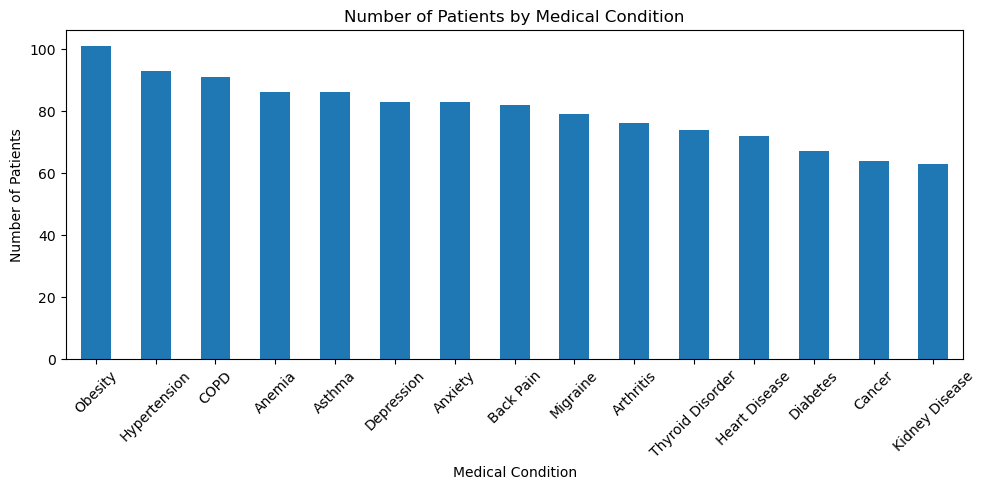

In [5]:
condition_count = df['Medical_Condition'].value_counts()

print(condition_count)
plt.figure(figsize=(10,5))
condition_count.plot(kind='bar')

plt.title('Number of Patients by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Treatment_Outcome
Improved        408
Stable          316
Recovered       287
Deteriorated    133
Deceased         56
Name: count, dtype: int64


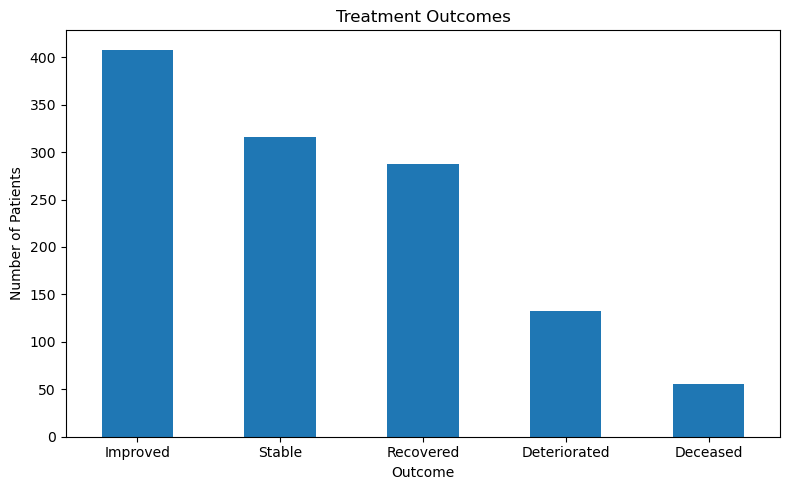

In [6]:
outcome_count = df['Treatment_Outcome'].value_counts()

print(outcome_count)
plt.figure(figsize=(8,5))
outcome_count.plot(kind='bar')

plt.title('Treatment Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Number of Patients')

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Readmitted
No     961
Yes    239
Name: count, dtype: int64


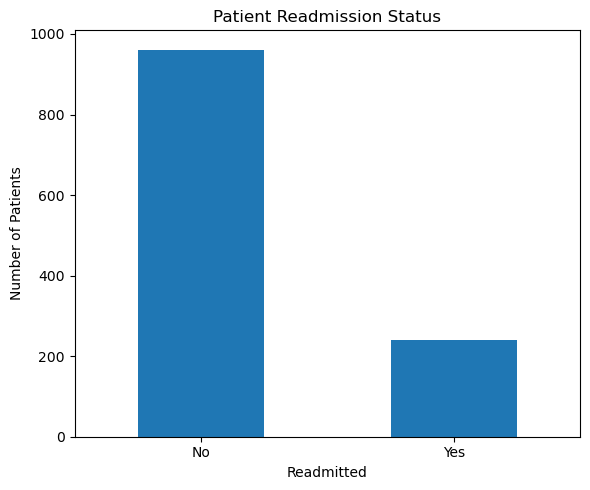

In [7]:
readmission_count = df['Readmitted'].value_counts()
print(readmission_count)
plt.figure(figsize=(6,5))
readmission_count.plot(kind='bar')
plt.title('Patient Readmission Status')
plt.xlabel('Readmitted')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Department
Pulmonology         154
General Medicine    148
Oncology            144
Psychiatry          135
Orthopedics         133
Endocrinology       128
Cardiology          123
Nephrology          120
Neurology           115
Name: count, dtype: int64


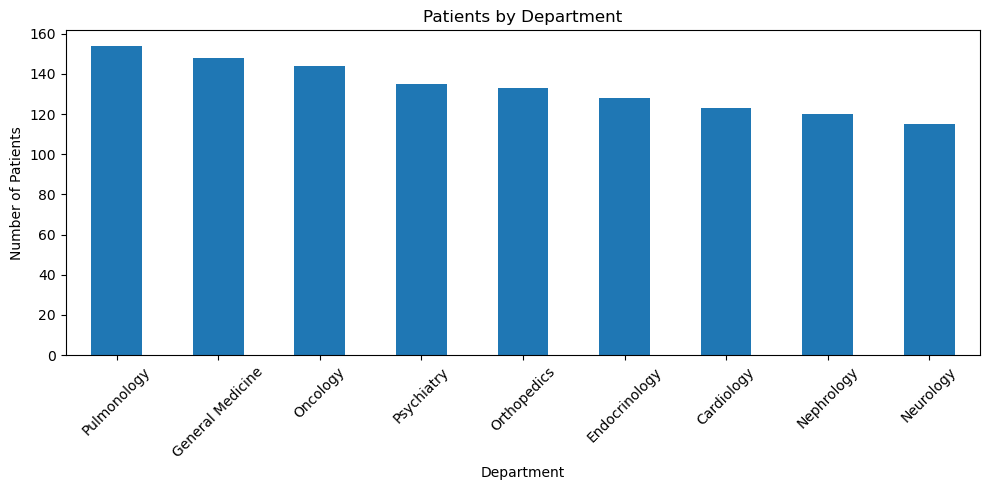

In [8]:
department_count = df['Department'].value_counts()

print(department_count)

plt.figure(figsize=(10,5))
department_count.plot(kind='bar')

plt.title('Patients by Department')
plt.xlabel('Department')
plt.ylabel('Number of Patients')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Average Treatment Cost: 25389.83
Maximum Treatment Cost: 49985.47
Minimum Treatment Cost: 528.07


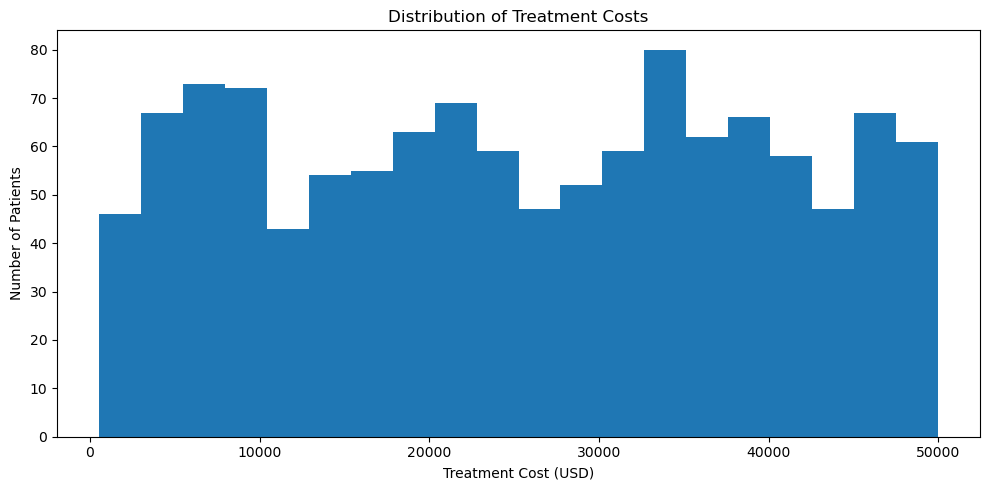

In [9]:
print("Average Treatment Cost:", round(df['Treatment_Cost_USD'].mean(), 2))
print("Maximum Treatment Cost:", round(df['Treatment_Cost_USD'].max(), 2))
print("Minimum Treatment Cost:", round(df['Treatment_Cost_USD'].min(), 2))

plt.figure(figsize=(10,5))
plt.hist(df['Treatment_Cost_USD'], bins=20)

plt.title('Distribution of Treatment Costs')
plt.xlabel('Treatment Cost (USD)')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

Average Satisfaction Score: 5.43
Highest Satisfaction Score: 10
Lowest Satisfaction Score: 1


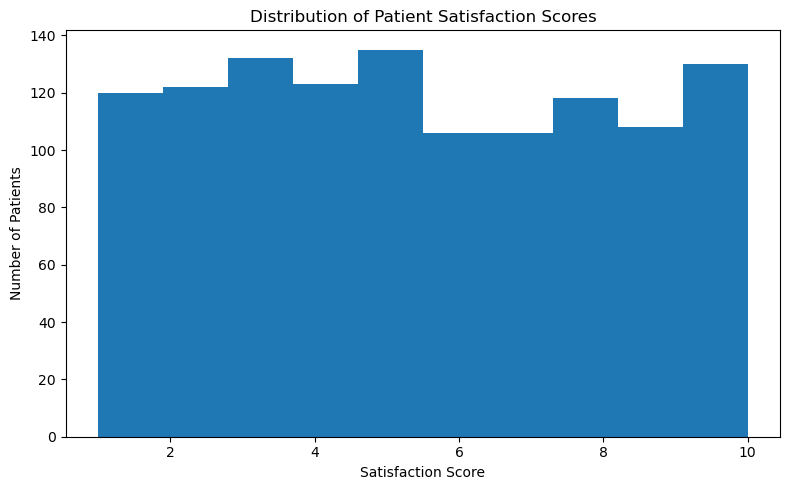

In [10]:
print("Average Satisfaction Score:", round(df['Satisfaction_Score'].mean(), 2))
print("Highest Satisfaction Score:", df['Satisfaction_Score'].max())
print("Lowest Satisfaction Score:", df['Satisfaction_Score'].min())

plt.figure(figsize=(8,5))
plt.hist(df['Satisfaction_Score'], bins=10)

plt.title('Distribution of Patient Satisfaction Scores')
plt.xlabel('Satisfaction Score')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

                          Age  Length_of_Stay_Days  Satisfaction_Score  \
Age                  1.000000             0.043442           -0.035278   
Length_of_Stay_Days  0.043442             1.000000            0.036613   
Satisfaction_Score  -0.035278             0.036613            1.000000   
BP_Systolic          0.008955             0.017645           -0.041381   
BP_Diastolic         0.043327            -0.062837           -0.012299   
Heart_Rate          -0.015340            -0.019443            0.004121   
Glucose_Level       -0.020384             0.005077            0.017061   
BMI                  0.001103             0.018668            0.025941   
Cholesterol          0.021257             0.005715           -0.027026   
Treatment_Cost_USD   0.008641             0.037783            0.026286   

                     BP_Systolic  BP_Diastolic  Heart_Rate  Glucose_Level  \
Age                     0.008955      0.043327   -0.015340      -0.020384   
Length_of_Stay_Days     0.01764

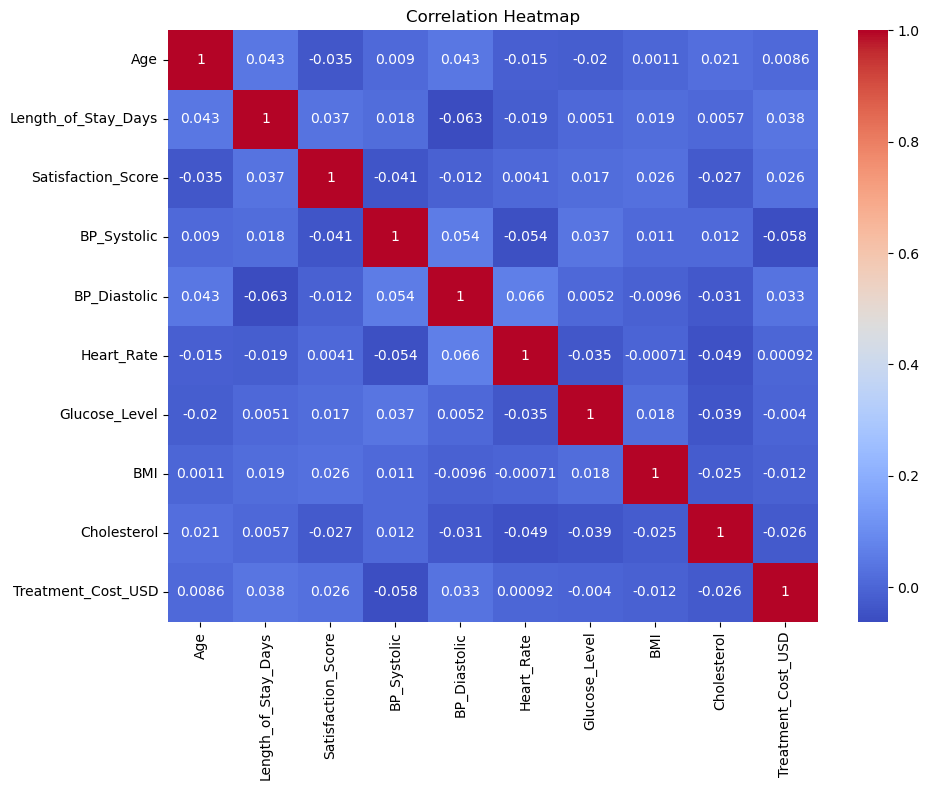

In [11]:
numeric_cols = [
    'Age',
    'Length_of_Stay_Days',
    'Satisfaction_Score',
    'BP_Systolic',
    'BP_Diastolic',
    'Heart_Rate',
    'Glucose_Level',
    'BMI',
    'Cholesterol',
    'Treatment_Cost_USD'
]

correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [12]:

df.to_csv("healthcare_cleaned.csv", index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!


In [14]:
import os

print(os.getcwd())

C:\Users\Arya
